In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix

In [36]:
X,y=make_circles(
    n_samples=500,
    factor=0.3,
    random_state=42,
    noise=0.25
)

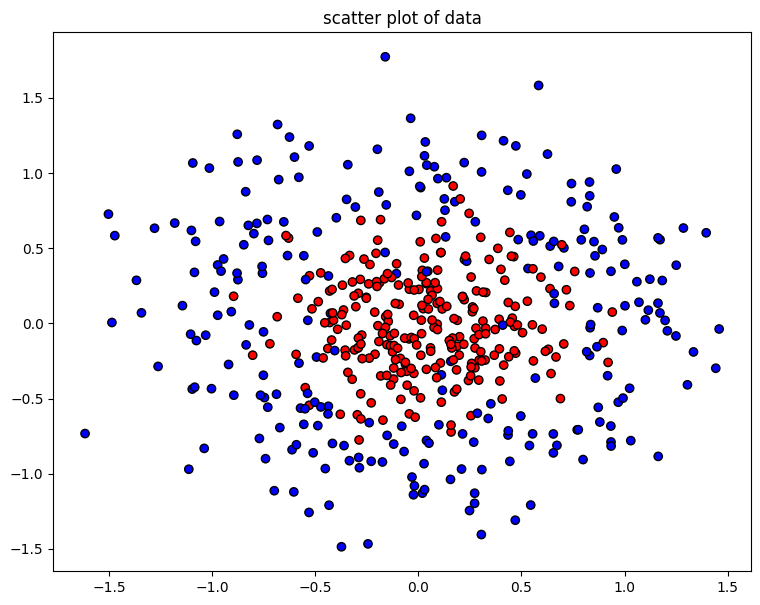

In [37]:
plt.figure(figsize=(9,7))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',edgecolors='k')
plt.title("scatter plot of data")
plt.show()

In [38]:
kernels={
    "linear":SVC(kernel='linear'),
    "polynomial":SVC(kernel='poly'),
    "rbf":SVC(kernel='rbf',gamma=1.5)
}

In [39]:
for name,model in kernels.items():
    model.fit(X,y)
    y_pred=model.predict(X)
    acc=accuracy_score(y_pred,y)
    print("the accuracy score is:",accuracy_score(y_pred,y))
    print(f"{name}kERNEL NAME:{acc:.3f}")

the accuracy score is: 0.62
linearkERNEL NAME:0.620
the accuracy score is: 0.588
polynomialkERNEL NAME:0.588
the accuracy score is: 0.898
rbfkERNEL NAME:0.898


In [40]:
rbf_model=kernels["rbf"]

In [41]:
xx,yy=np.meshgrid(
    np.linspace(X[:,0].min()-0.2,X[:,0].max()+0.2,200),
    np.linspace(X[:,1].min()-0.2,X[:,1].max()+0.2,200)
)

In [42]:
grid=np.c_[xx.ravel(),yy.ravel()]


In [43]:
Z = rbf_model.predict(grid).reshape(xx.shape)

C:\Users\zaima\AppData\Local\Temp\ipykernel_27860\2269863594.py:2: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  plt.contour(


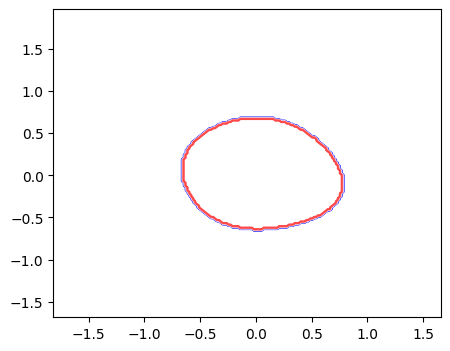

In [44]:
plt.figure(figsize=(5,4))
plt.contour(
    xx,
    yy,
    Z,
  cmap='bwr',

edgecolor="k")

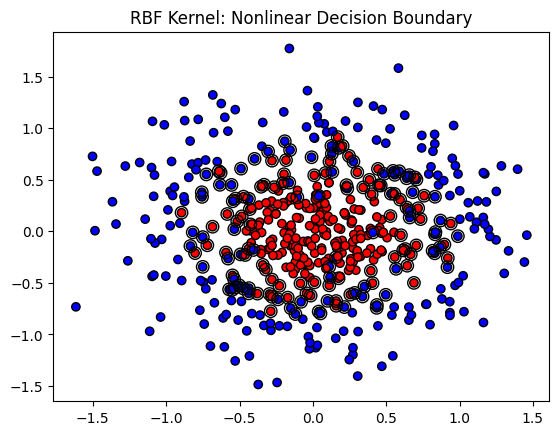

In [45]:
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)
plt.scatter(
    rbf_model.support_vectors_[:,0],
    rbf_model.support_vectors_[:,1],
    s=80,
    facecolors="none",
    edgecolors="black"
)
plt.title("RBF Kernel: Nonlinear Decision Boundary")
plt.show()